In [ ]:
# Data-path configuration (see ../paths.py and ../DATA.md).
# Set the SCREAM_AUTOTUNE_DATA env var to point at the unpacked Zenodo
# data deposit; defaults to <repo>/data. Assumes this notebook is run
# from its own directory (the Jupyter default).
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import paths


# Preprocessing and KFolds surrogate training workflow


Load in packages - Tensorflow warnings may affect ESEM GP performance

In [1]:
import os
import json
import math
import pandas as pd
import numpy as np
import xarray as xr
import glob
import pickle
from esem import gp_model, cnn_model, rf_model
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, r2_score, root_mean_squared_error
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline

import tensorflow as tf
import gpflow
from datetime import date
from datetime import datetime

from scipy.optimize import minimize

2026-06-18 14:44:51.327995: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-18 14:44:51.328045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-18 14:44:51.443165: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-18 14:44:51.537339: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Running the models

### Load the files/parameters/variables

Load parameter sampling

In [95]:
path_to_json = str(paths.PPE_PARAMS_JSON) #this file contains the specific parameters for each run
ppe_params_all = pd.read_json(path_to_json)

In [96]:
(ppe_params_all['p3_ice_sed_knob']>=1).sum() #number of ppe runs with required restricted parameter ranges

162

In [97]:
##collects the labels for all runs --- DY2
DY2_path = str(paths.DY2_DIR) + "/" #path to the runs
DY2_missing_folders =[] #will collect all removed runs
DY2_folders = []

#Reading in all file folders
#m**** files
    #When trying increasing amounts of data we will go with up to 50, 100, 150, 200, 287
for m in range(0, 301): #DY1 goes to 301
    folder = 'm{:04}'.format(m)
    if os.path.exists(DY2_path+folder):
        DY2_folders.append(m)
    else:
        DY2_missing_folders.append(m) #just in integers, not file name (if you want this append folder)  
DY2_folders = ['m{:04}'.format(m) for m in DY2_folders] #writes the runs in the m**** format
#opt**** files
for file in os.listdir(DY2_path):
    #if file.startswith("m0") or file.startswith("opt"):
    if file.startswith("opt"):
        DY2_folders.append(file)
#does not include t0000 as this is pointed to by m0000

#removing files that don't have all the data--could be doing this better
DY2_folders.remove('m0230') #this file is missing 3hr averages
DY2_folders.remove('optmar20day5') #this file is missing 2nd day daily averages

#not in DY1
DY2_folders.remove('m0024')
DY2_folders.remove('m0025')
DY2_folders.remove('m0061')
DY2_folders.remove('optmar22hd')
DY2_folders.remove('optmar15')
DY2_folders.remove('optmar20day2')

print(len(DY2_folders)) 
DY2_folders = sorted(DY2_folders)

##adds the path name for all files--only 2nd day, daily averages
DY2_filename_list = []
DY2_data_dir = DY2_path #'/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/SCREAM.2024-autocal-00.ne1024pg2/'
#data_dir = '/global/cfs/projectdirs/e3smdata/simulations/SCREAM.2024-autocal-00.ne1024pg2/' #pointed to by above
for f in DY2_folders:
    file_path = DY2_data_dir+f+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
    #file_path1 = data_dir+f+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-20-00000.nc'
    #file_path2 = data_dir+f+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2020-01-26-00000.nc'
    DY2_filename_list.append(file_path)

#count_fail = 0
##filter ice_sed < 1 to exclude runs outside of typical range
DY2_file_check = np.zeros(len(DY2_filename_list),dtype=bool) #initialize file check
for i in range(len(DY2_filename_list)):
    ppe_member = DY2_folders[i]
    if (float(ppe_params_all['p3_ice_sed_knob'][ppe_member]) >= 1.0):
        DY2_file_check[i] = True
#    else:
#        count_fail += 1
#print(count_fail)

DY2_filename_list_filtered = np.array(DY2_filename_list)[DY2_file_check==True] #turns the file name list to a np array
DY2_sim_names = np.array(DY2_folders)[DY2_file_check==True]
DY2_ppe_params = ppe_params_all[ppe_params_all.index.isin(DY2_sim_names)]
len(DY2_ppe_params)

226


153

In [98]:
##collects the labels for all runs --- DY1
DY1_path = str(paths.DY1_DIR) + "/" #new scratch location of DY1
#"/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-s15-mar7/setupA1/" #previous path to the runs
DY1_missing_folders =[] #will collect all removed runs
DY1_folders = []

#When trying increasing amounts of data we will go with up to 50, 100, 150, 200, 287 (this is where DY2 ends)
for m in range(0, 301): 
    folder = 'm{:04}'.format(m)
    if os.path.exists(DY1_path+folder):
        DY1_folders.append(m)
    else:
        DY1_missing_folders.append(m) #just in integers, not file name (if you want this append folder)  
DY1_folders = ['m{:04}'.format(m) for m in DY1_folders] #writes the runs in the m**** format

#Could also pull all files in this way, but will be out of order and include m0000-5day
for file in os.listdir(DY1_path):
    #if file.startswith("m0") or file.startswith("opt"):
    if file.startswith("opt"):
        DY1_folders.append(file)
#does not include t0000 as this is pointed to by m0000

#removing files that don't have all the data
#folders.remove('m0230') #this file is missing 3hr averages
#folders.remove('optmar20day5') #this file is missing 2nd day daily averages

#DY2 -- invalid runs -- also not in the json
DY1_folders.remove('m0024')
DY1_folders.remove('m0025')
DY1_folders.remove('m0061')
DY1_folders.remove('optmar22hd')

DY1_folders.remove('m0262')
DY1_folders.remove('m0263')
DY1_folders.remove('m0264')
DY1_folders.remove('m0266')
DY1_folders.remove('m0267')
DY1_folders.remove('m0270')
DY1_folders.remove('m0272')
DY1_folders.remove('m0274')
DY1_folders.remove('m0275')
DY1_folders.remove('m0279')
DY1_folders.remove('m0289')
DY1_folders.remove('m0290')
DY1_folders.remove('m0292')
DY1_folders.remove('m0293')
DY1_folders.remove('m0294')
DY1_folders.remove('m0295')
DY1_folders.remove('m0296')
DY1_folders.remove('m0299')
DY1_folders.remove('m0300')

DY1_folders.remove('optmar15seed0')
DY1_folders.remove('optmar27a')
DY1_folders.remove('optmar20dayAll')
DY1_folders.remove('optmar20day2-fail')
DY1_folders.remove('optmar15b')
DY1_folders.remove('optmar20day2-ltend')

#Not in DY2
DY1_folders.remove('m0230')
DY1_folders.remove('optmar20day5')
print(len(DY1_folders))
DY1_folders = sorted(DY1_folders)

##adds the path name for all files--only 2nd day, daily averages
DY1_filename_list = []
DY1_data_dir = DY1_path #'/global/cfs/cdirs/e3smdata/simulations/ecp-autotune/sims-s15-mar7/setupA1/'
#data_dir = '/global/cfs/projectdirs/e3smdata/simulations/SCREAM.2024-autocal-00.ne1024pg2/' #pointed to by above
for f in DY1_folders:
    file_path = DY1_data_dir+f+'/SCREAM.2024-autocal-00.ne1024pg2/run/output.scream.AutoCal.daily_avg_ne30pg2.AVERAGE.nhours_x24.2016-08-07-00000.nc'
    DY1_filename_list.append(file_path)
    
##filter ice_sed < 1 to exclude runs outside of typical range
DY1_file_check = np.zeros(len(DY1_filename_list),dtype=bool) #initialize file check
for i in range(len(DY1_filename_list)):
    ppe_member = DY1_folders[i]
    #if (int(sim_names[i][1:]) < 265): #try it with all the runs
    if (float(ppe_params_all['p3_ice_sed_knob'][ppe_member]) >= 1.0):
        DY1_file_check[i] = True

DY1_filename_list_filtered = np.array(DY1_filename_list)[DY1_file_check==True] #turns the file name list to a np array
DY1_sim_names = np.array(DY1_folders)[DY1_file_check==True]
DY1_ppe_params = ppe_params_all[ppe_params_all.index.isin(DY1_sim_names)]
len(DY1_ppe_params)

153


153

In [99]:
#Check for intersection between DY1 and DY2, take only runs in both
print(list(set(DY1_sim_names) - set(DY2_sim_names))) # should be empty
print(list(set(DY2_sim_names) - set(DY1_sim_names)))
sim_names = [sim for sim in DY1_sim_names if sim in DY2_sim_names] 

ppe_params = ppe_params_all.loc[sim_names]
ppe_params

[]
[]


,thl2tune,qw2tune,length_fac,c_diag_3rd_mom,Ckh,Ckm,lambda_low,lambda_high,p3_spa_to_nc,p3_eci,p3_eri,p3_k_accretion,p3_dep_nucleation_exponent,max_total_ni,p3_ice_sed_knob,p3_d_breakup_cutoff
m0000,1.000000,1.000000,0.500000,7.000000,0.100000,0.100000,0.001000,0.080000,1.000000,0.500000,1.000000,67.000000,0.304000,7.400000e+05,1.000000,0.000280
m0001,4.137687,5.666304,2.811901,5.501111,0.652841,0.710080,0.005563,0.096491,1.570424,0.155626,0.376260,76.607768,0.287172,7.871913e+06,1.901109,0.000171
m0003,2.866048,2.371165,2.725004,2.854489,0.451758,0.534356,0.080412,0.084454,1.238399,0.730820,0.415506,69.788644,0.233476,3.060179e+06,1.203110,0.000054
m0004,0.637033,2.042104,4.520450,5.810468,0.761983,0.827704,0.051414,0.058209,6.168379,0.942799,0.627808,46.754044,0.259327,6.217520e+06,1.015339,0.000338
m0005,8.259702,7.669089,8.095844,4.861493,0.415421,0.428636,0.041455,0.080530,2.349736,0.124933,0.903137,4.591789,0.230274,3.297805e+06,1.475973,0.000109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
optmar26c,0.243387,10.000000,8.262705,0.724895,0.100000,0.100000,0.074718,0.094955,0.506955,0.750758,0.100000,0.010000,0.281757,7.585755e+06,1.000000,0.000000
optmar26d,1.482697,2.022770,0.824637,0.100000,1.000000,1.000000,0.000100,0.100000,1.624859,0.976114,0.863507,11.604578,0.221555,5.000000e+05,1.437345,0.000275
optmar26e,9.447644,2.199758,8.263428,4.618708,0.376983,0.165133,0.063569,0.098370,0.113968,0.126743,0.956913,0.013569,0.200728,2.518995e+06,1.032081,0.000006
optmar26f,9.794405,9.784599,8.750237,10.000000,0.234083,0.232806,0.049321,0.061612,0.331467,0.126517,1.000000,0.010000,0.279258,8.653190e+06,1.355044,0.000000


In [100]:
# Open and concatenate the datasets along the new 'run_number' dimension
DY1_concat_dataset = xr.open_mfdataset(DY1_filename_list_filtered, concat_dim='run_label', combine='nested')
DY1_sim_names_from_paths = [path.split('/')[-4] for path in DY1_filename_list_filtered]
DY1_ppe_dataset_time = DY1_concat_dataset.assign_coords(run_label=('run_label', DY1_sim_names_from_paths))
#DY1_ppe_dataset_time = DY1_concat_dataset.assign_coords(run_label=('run_label', DY1_sim_names)) # Assign the 'run_number' coordinate
DY1_ppe_dataset = DY1_ppe_dataset_time.squeeze('time')


In [101]:
# Open and concatenate the datasets along the new 'run_number' dimension
DY2_concat_dataset = xr.open_mfdataset(DY2_filename_list_filtered, concat_dim='run_label', combine='nested')
DY2_sim_names_from_paths = [path.split('/')[-4] for path in DY2_filename_list_filtered]
DY2_ppe_dataset_time = DY2_concat_dataset.assign_coords(run_label=('run_label', DY2_sim_names_from_paths))
#DY2_ppe_dataset_time = DY2_concat_dataset.assign_coords(run_label=('run_label', DY2_sim_names)) # Assign the 'run_number' coordinate
DY2_ppe_dataset = DY2_ppe_dataset_time.squeeze('time')


##### Observations

In [102]:
DY1_obs_dir = str(paths.DY1_OBS_DIR) + '/'
DY1_precip_obs_file = DY1_obs_dir + 'IMERG.precip_total_surf_mass_flux.daily_AVERAGE.ne30pg2.20160807_mahf708.nc' #maybe check this
DY1_LW_obs_file = DY1_obs_dir + 'CERES.LW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
#DY1_SW_dn_obs_file = DY1_obs_dir + 'CERES.SW_flux_dn_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_SW_up_obs_file = DY1_obs_dir + 'CERES.SW_flux_up_at_model_top.daily_AVERAGE.ne30pg2.20160807_mahf708.nc'
DY1_LWP_file = DY1_obs_dir + 'mac.clwp-tlwp-wvp.20160807.ne30pg2.nc'

DY1_PCP_obs = xr.open_dataset(DY1_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY1_TLWP_obs = (xr.open_dataset(DY1_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY1_OSR_obs = xr.open_dataset(DY1_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY1_OLR_obs = xr.open_dataset(DY1_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

In [103]:
DY2_obs_dir = str(paths.DY2_OBS_DIR) + '/'
DY2_precip_obs_file = DY2_obs_dir + 'IMERG.precip_total_surf_mass_flux.AVERAGE.ne30pg2.20200126.nc'
DY2_LW_obs_file = DY2_obs_dir + 'CERES.LW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
#DY2_SW_dn_obs_file = DY2_obs_dir + 'CERES.SW_flux_dn_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_SW_up_obs_file = DY2_obs_dir + 'CERES.SW_flux_up_at_model_top.AVERAGE.ne30pg2.20200126.nc'
DY2_LWP_file = DY2_obs_dir + 'mac.clwp-tlwp-wvp.20200126.ne30pg2.nc'

DY2_PCP_obs = xr.open_dataset(DY2_precip_obs_file).variables['precip_total_surf_mass_flux'].squeeze('time')
DY2_TLWP_obs = (xr.open_dataset(DY2_LWP_file).variables['tlwp']*1e-3).squeeze('time')
DY2_OSR_obs = xr.open_dataset(DY2_SW_up_obs_file).variables['SW_flux_up_at_model_top'].squeeze('time')
DY2_OLR_obs = xr.open_dataset(DY2_LW_obs_file).variables['LW_flux_up_at_model_top'].squeeze('time')

##### Filter data

In [104]:
#filter variables in output - keep only the 4 of interest
to_keep = ['precip_total_surf_mass_flux','LiqWaterPath','RainWaterPath','SW_flux_up_at_model_top','LW_flux_up_at_model_top']
           
to_leave = ['SW_flux_dn','SW_flux_dn_at_model_bot','SW_flux_up','SW_flux_up_at_model_bot','SW_flux_dn_at_model_top', 'T_2m',
'T_mid', 'precip_ice_surf_mass_flux','precip_liq_surf_mass_flux','ps','qc','qi','qm','qr','qv','qv_2m','LW_flux_up','LW_flux_up_at_model_bot',
'IceWaterPath', 'LW_flux_dn','LW_flux_dn_at_model_bot','time_bnds', 'LongwaveCloudForcing', 'MeridionalVapFlux','ShortwaveCloudForcing','U','V', 
'VapWaterPath', 'ZonalVapFlux','bm','eddy_diff_mom', 'eff_radius_qc_at_cldtop','eff_radius_qi_at_cldtop', 'homme_T_mid_tend', 'homme_qv_tend',
'horiz_winds_at_model_bot', 'nc', 'ni', 'nr', 'omega', 'p3_T_mid_tend', 'p3_qv_tend', 'rrtmgp_T_mid_tend', 'sgs_buoy_flux', 'shoc_T_mid_tend',
'shoc_qv_tend', 'surf_evap', 'surf_mom_flux', 'surf_radiative_T','surf_sens_flux', 'surface_upward_latent_heat_flux', 'avg_count_ncol', 
'avg_count_ncol_lev', 'avg_count_ncol_dim', 'area', 'lat', 'lon']

In [105]:
DY1_ppe_dataset_small = DY1_ppe_dataset.drop_vars(to_leave)
DY1_ppe_dataset_small['TotalLiqWaterPath'] = (DY1_ppe_dataset_small.LiqWaterPath + DY1_ppe_dataset_small.RainWaterPath)
#ppe_dataset_small['precip_total_surf_mass_flux'] = ppe_dataset_small['precip_total_surf_mass_flux']*1e-3*24*3600
DY1_ppe_dataset_small = DY1_ppe_dataset_small.drop_vars('p_levs')
DY1_ppe_dataset_small = DY1_ppe_dataset_small.rename({var: f"DY1_{var}" for var in DY1_ppe_dataset_small.data_vars})

In [106]:
DY2_ppe_dataset_small = DY2_ppe_dataset.drop_vars(to_leave)
DY2_ppe_dataset_small['TotalLiqWaterPath'] = (DY2_ppe_dataset_small.LiqWaterPath + DY2_ppe_dataset_small.RainWaterPath)
#ppe_dataset_small['precip_total_surf_mass_flux'] = ppe_dataset_small['precip_total_surf_mass_flux']*1e-3*24*3600]
#DY2_ppe_dataset_small = DY2_ppe_dataset_small.drop_vars('p_levs')
DY2_ppe_dataset_small = DY2_ppe_dataset_small.rename({var: f"DY2_{var}" for var in DY2_ppe_dataset_small.data_vars})

In [107]:
assert list(ppe_params.index) == sim_names
assert list(DY1_ppe_dataset_small.run_label.values) == sim_names
assert list(DY2_ppe_dataset_small.run_label.values) == sim_names

In [108]:
#ppe_dataset_small = xr.concat([DY1_ppe_dataset_small, DY2_ppe_dataset_small], dim='run_label')
ppe_dataset_small = DY1_ppe_dataset_small.sel(run_label=sim_names).combine_first(DY2_ppe_dataset_small.sel(run_label=sim_names))
ppe_dataset_small

<xarray.Dataset> Size: 159MB
Dimensions:                          (run_label: 153, ncol: 21600)
Coordinates:
  * run_label                        (run_label) <U10 6kB 'm0000' ... 'optmar5'
Dimensions without coordinates: ncol
Data variables:
    DY1_LW_flux_up_at_model_top      (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY1_LiqWaterPath                 (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY1_RainWaterPath                (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY1_SW_flux_up_at_model_top      (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY1_precip_total_surf_mass_flux  (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY1_TotalLiqWaterPath            (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY2_LW_flux_up_at_model_top      (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY2_LiqWaterPath                 (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY2_RainWaterPath                (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY2_SW_flux_up_at_model_top      (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY2_precip_total_surf_mass_flux  (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
    DY2_TotalLiqWaterPath            (run_label, ncol) float32 13MB dask.array<chunksize=(1, 21600), meta=np.ndarray>
Attributes: (12/23)
    institutions:                 LLNL (Lawrence Livermore National Laborator...
    case_t0:                      2016-08-01-00000
    run_t0:                       2016-08-06-00000
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          24
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Projet
    realm:                        atmos
    history:                      created on Sat Mar  9 20:33:59 2024
    Conventions:                  CF-1.8
    product:                      model-output

#### Taking spatial averages - zonal, regional, global

##### Mask to observations
Observations are available on a subset of grid cells; this will affect averages, so first mask to the subset of grid cells

In [ ]:
##two ways to get these masks
mask_path =str(paths.MASK_DIR) + '/'

DY1_PCP_mask = xr.open_dataset(mask_path+'/masks/precip_1_output.nc').squeeze('time', drop=True)
DY2_PCP_mask = xr.open_dataset(mask_path+'/masks/precip_2_output.nc').squeeze('time', drop=True)
DY1_TLWP_mask = xr.open_dataset(mask_path+'/masks/tlwp_1_output.nc').squeeze('time', drop=True)
DY2_TLWP_mask = xr.open_dataset(mask_path+'/masks/tlwp_2_output.nc').squeeze('time', drop=True)

#len(np.where(((DY1_TLWP_mask.to_dataarray()[0]) == True).values)[0]) - ncol drops from 21600 to 15313

In [ ]:
DY1_ppe_dataset_mask = DY1_ppe_dataset_small.copy(deep=True)
DY2_ppe_dataset_mask = DY2_ppe_dataset_small.copy(deep=True)

#DY1
DY1_ppe_dataset_mask['DY1_precip_total_surf_mass_flux'] = DY1_ppe_dataset_small.DY1_precip_total_surf_mass_flux.where(np.isnan(DY1_PCP_obs) == False)
DY1_ppe_dataset_mask['DY1_TotalLiqWaterPath'] = DY1_ppe_dataset_small.DY1_TotalLiqWaterPath.where(np.isnan(DY1_TLWP_obs) == False)
DY1_ppe_dataset_mask['DY1_SW_flux_up_at_model_top'] = DY1_ppe_dataset_small.DY1_SW_flux_up_at_model_top.where(np.isnan(DY1_OSR_obs) == False)
DY1_ppe_dataset_mask['DY1_LW_flux_up_at_model_top'] = DY1_ppe_dataset_small.DY1_LW_flux_up_at_model_top.where(np.isnan(DY1_OLR_obs) == False)

#DY2
DY2_ppe_dataset_mask['DY2_precip_total_surf_mass_flux'] = DY2_ppe_dataset_small.DY2_precip_total_surf_mass_flux.where(np.isnan(DY2_PCP_obs) == False)
DY2_ppe_dataset_mask['DY2_TotalLiqWaterPath'] = DY2_ppe_dataset_small.DY2_TotalLiqWaterPath.where(np.isnan(DY2_TLWP_obs) == False)
DY2_ppe_dataset_mask['DY2_SW_flux_up_at_model_top'] = DY2_ppe_dataset_small.DY2_SW_flux_up_at_model_top.where(np.isnan(DY2_OSR_obs) == False)
DY2_ppe_dataset_mask['DY2_LW_flux_up_at_model_top'] = DY2_ppe_dataset_small.DY2_LW_flux_up_at_model_top.where(np.isnan(DY2_OLR_obs) == False)

In [ ]:
regions_file = xr.open_dataset(str(paths.REGIONS_FILE))
regions_list = ['poles','extratropical_land','extratropical_ocean','tropical_land','ascending_tropical_ocean','descending_tropical_ocean']
#area = ppe_dataset.area[1,:] #only taking the first row, because all rows should have the same values
control = xr.open_dataset(str(paths.CONTROL_FILE))
area = control.variables['area'][:]
lat = control.variables['lat'][:]
lon = control.variables['lon'][:]

In [ ]:
def zonal_means_native(data, area, lat, lon):
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    lat = lat.squeeze()
    lat_bands = np.linspace(-90, 90, 19) #currently dividing globe in 18 zones via 19 borders - 10 degree bands
    zonal_means = dict()
    for i in range(len(lat_bands) - 1):
        mask_zone = (lat >= lat_bands[i]) & (lat < lat_bands[i+1]) #includes lower bound in the band (! might cause missing north pole)
        data_zone = np.where(mask_zone, data, np.nan)
        area_zone = np.where(mask_zone, masked_area, np.nan)
        zone_center = lat_bands[i] + (lat_bands[i+1] - lat_bands[i])/2
        if np.all(np.isnan(data_zone)) or np.nansum(area_zone) == 0:
            zonal_means[zone_center] = np.nan
        else:
            zone_mean = np.nansum(data_zone * area_zone) / np.nansum(area_zone)
            zonal_means[zone_center] = zone_mean
    return zonal_means

def regional_means_native(data, area, region_data):  
    #region_data = xr.open_dataset('/global/cfs/projectdirs/e3smdata/simulations/ecp-autotune/regions.nc') #for performance improvement move region_data out as argument
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    regions_list = ['poles', 'extratropical_land', 'extratropical_ocean', 
                    'tropical_land', 'ascending_tropical_ocean', 'descending_tropical_ocean']
    region_means = dict()
    for reg_name in regions_list:
        mask_reg = region_data[reg_name].squeeze()
        data_reg = np.where(mask_reg > 0, data, np.nan)
        area_reg = np.where(mask_reg > 0, masked_area, np.nan)
        if np.all(np.isnan(data_reg)) or np.nansum(area_reg) == 0:
            region_means[reg_name] = np.nan
        else:
            reg_mean = np.nansum(data_reg * area_reg) / np.nansum(area_reg)
            region_means[reg_name] = reg_mean
    return region_means

def global_means_native(data, area): #takes global averages
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    global_mean = np.nansum(data*masked_area)/np.nansum(masked_area)
    return global_mean

Below we are just taking the averages

In [ ]:
def zonal_means_native_print(data, area, lat, lon):
    data = data.squeeze()
    masked_area = np.where(np.isnan(data), np.nan, area).squeeze()
    lat = lat.squeeze()
    lat_bands = np.linspace(-90, 90, 19) #currently dividing globe in 18 zones via 19 borders - 10 degree bands
    zonal_means = dict()
    for i in range(len(lat_bands) - 1):
        mask_zone = (lat >= lat_bands[i]) & (lat < lat_bands[i+1]) #includes lower bound in the band (! might cause missing north pole)
        data_zone = np.where(mask_zone, data, np.nan)
        print(21600 - np.sum(np.isnan(data_zone)))
        area_zone = np.where(mask_zone, masked_area, np.nan)
        zone_center = lat_bands[i] + (lat_bands[i+1] - lat_bands[i])/2
        if np.all(np.isnan(data_zone)) or np.nansum(area_zone) == 0:
            zonal_means[zone_center] = np.nan
        else:
            zone_mean = np.nansum(data_zone * area_zone) / np.nansum(area_zone)
            zonal_means[zone_center] = zone_mean
    return zonal_means

In [ ]:
DY1_PCP_zonal_data = dict()
DY1_TLWP_zonal_data = dict()
DY1_OSR_zonal_data = dict()
DY1_OLR_zonal_data = dict()

DY1_PCP_regional_data = dict()
DY1_TLWP_regional_data = dict()
DY1_OSR_regional_data = dict()
DY1_OLR_regional_data = dict()

DY1_PCP_global_data = []
DY1_TLWP_global_data = []
DY1_OSR_global_data = []
DY1_OLR_global_data = []

for run in sim_names:
    precip = DY1_ppe_dataset_mask.sel(run_label = run)['DY1_precip_total_surf_mass_flux']
    tlwp = DY1_ppe_dataset_mask.sel(run_label = run)['DY1_TotalLiqWaterPath']
    swflux = DY1_ppe_dataset_mask.sel(run_label = run)['DY1_SW_flux_up_at_model_top']
    lwflux = DY1_ppe_dataset_mask.sel(run_label = run)['DY1_LW_flux_up_at_model_top']

    DY1_PCP_zonal_data[run] = zonal_means_native(precip, area, lat, lon)
    DY1_TLWP_zonal_data[run] = zonal_means_native(tlwp, area, lat, lon)
    DY1_OSR_zonal_data[run] = zonal_means_native(swflux, area, lat, lon)
    DY1_OLR_zonal_data[run] = zonal_means_native(lwflux, area, lat, lon)
    
    DY1_PCP_regional_data[run] = regional_means_native(precip, area, regions_file)
    DY1_TLWP_regional_data[run] = regional_means_native(tlwp, area, regions_file)
    DY1_OSR_regional_data[run] = regional_means_native(swflux, area, regions_file)
    DY1_OLR_regional_data[run] = regional_means_native(lwflux, area, regions_file)    
    
    DY1_PCP_global_data.append(global_means_native(precip, area))
    DY1_TLWP_global_data.append(global_means_native(tlwp, area))
    DY1_OSR_global_data.append(global_means_native(swflux, area))
    DY1_OLR_global_data.append(global_means_native(lwflux, area))

In [ ]:
DY2_PCP_zonal_data = dict()
DY2_TLWP_zonal_data = dict()
DY2_OSR_zonal_data = dict()
DY2_OLR_zonal_data = dict()

DY2_PCP_regional_data = dict()
DY2_TLWP_regional_data = dict()
DY2_OSR_regional_data = dict()
DY2_OLR_regional_data = dict()

DY2_PCP_global_data = []
DY2_TLWP_global_data = []
DY2_OSR_global_data = []
DY2_OLR_global_data = []

for run in sim_names:
    precip = DY2_ppe_dataset_mask.sel(run_label = run)['DY2_precip_total_surf_mass_flux']
    tlwp = DY2_ppe_dataset_mask.sel(run_label = run)['DY2_TotalLiqWaterPath']
    swflux = DY2_ppe_dataset_mask.sel(run_label = run)['DY2_SW_flux_up_at_model_top']
    lwflux = DY2_ppe_dataset_mask.sel(run_label = run)['DY2_LW_flux_up_at_model_top']

    DY2_PCP_zonal_data[run] = zonal_means_native(precip, area, lat, lon)
    DY2_TLWP_zonal_data[run] = zonal_means_native(tlwp, area, lat, lon)
    DY2_OSR_zonal_data[run] = zonal_means_native(swflux, area, lat, lon)
    DY2_OLR_zonal_data[run] = zonal_means_native(lwflux, area, lat, lon)
    
    DY2_PCP_regional_data[run] = regional_means_native(precip, area, regions_file)
    DY2_TLWP_regional_data[run] = regional_means_native(tlwp, area, regions_file)
    DY2_OSR_regional_data[run] = regional_means_native(swflux, area, regions_file)
    DY2_OLR_regional_data[run] = regional_means_native(lwflux, area, regions_file)    
    
    DY2_PCP_global_data.append(global_means_native(precip, area))
    DY2_TLWP_global_data.append(global_means_native(tlwp, area))
    DY2_OSR_global_data.append(global_means_native(swflux, area))
    DY2_OLR_global_data.append(global_means_native(lwflux, area))

In [ ]:
DY1_PCP_z_df = pd.DataFrame.from_dict(DY1_PCP_zonal_data, orient="index")
DY1_PCP_r_df = pd.DataFrame.from_dict(DY1_PCP_regional_data, orient="index")
DY1_PCP_zrg_ppedataset = pd.concat([DY1_PCP_z_df, DY1_PCP_r_df], axis=1)
DY1_PCP_zrg_ppedataset["global"] = DY1_PCP_global_data
DY1_PCP_zrg_ppedataset.columns = [f"DY1_{c}" for c in DY1_PCP_zrg_ppedataset.columns]

DY2_PCP_z_df = pd.DataFrame.from_dict(DY2_PCP_zonal_data, orient="index")
DY2_PCP_r_df = pd.DataFrame.from_dict(DY2_PCP_regional_data, orient="index")
DY2_PCP_zrg_ppedataset = pd.concat([DY2_PCP_z_df, DY2_PCP_r_df], axis=1)
DY2_PCP_zrg_ppedataset["global"] = DY2_PCP_global_data
DY2_PCP_zrg_ppedataset.columns = [f"DY2_{c}" for c in DY2_PCP_zrg_ppedataset.columns]

PCP_zrg_ppedataset = pd.concat([DY1_PCP_zrg_ppedataset, DY2_PCP_zrg_ppedataset], axis=1)

In [ ]:
DY1_TLWP_z_df = pd.DataFrame.from_dict(DY1_TLWP_zonal_data, orient="index")
DY1_TLWP_r_df = pd.DataFrame.from_dict(DY1_TLWP_regional_data, orient="index")
DY1_TLWP_zrg_ppedataset = pd.concat([DY1_TLWP_z_df, DY1_TLWP_r_df], axis=1)
DY1_TLWP_zrg_ppedataset["global"] = DY1_TLWP_global_data
DY1_TLWP_zrg_ppedataset.columns = [f"DY1_{c}" for c in DY1_TLWP_zrg_ppedataset.columns]

DY2_TLWP_z_df = pd.DataFrame.from_dict(DY2_TLWP_zonal_data, orient="index")
DY2_TLWP_r_df = pd.DataFrame.from_dict(DY2_TLWP_regional_data, orient="index")
DY2_TLWP_zrg_ppedataset = pd.concat([DY2_TLWP_z_df, DY2_TLWP_r_df], axis=1)
DY2_TLWP_zrg_ppedataset["global"] = DY2_TLWP_global_data
DY2_TLWP_zrg_ppedataset.columns = [f"DY2_{c}" for c in DY2_TLWP_zrg_ppedataset.columns]

TLWP_zrg_ppedataset = pd.concat([DY1_TLWP_zrg_ppedataset, DY2_TLWP_zrg_ppedataset], axis=1)

In [ ]:
DY1_OSR_z_df = pd.DataFrame.from_dict(DY1_OSR_zonal_data, orient="index")
DY1_OSR_r_df = pd.DataFrame.from_dict(DY1_OSR_regional_data, orient="index")
DY1_OSR_zrg_ppedataset = pd.concat([DY1_OSR_z_df, DY1_OSR_r_df], axis=1)
DY1_OSR_zrg_ppedataset["global"] = DY1_OSR_global_data
DY1_OSR_zrg_ppedataset.columns = [f"DY1_{c}" for c in DY1_OSR_zrg_ppedataset.columns]

DY2_OSR_z_df = pd.DataFrame.from_dict(DY2_OSR_zonal_data, orient="index")
DY2_OSR_r_df = pd.DataFrame.from_dict(DY2_OSR_regional_data, orient="index")
DY2_OSR_zrg_ppedataset = pd.concat([DY2_OSR_z_df, DY2_OSR_r_df], axis=1)
DY2_OSR_zrg_ppedataset["global"] = DY2_OSR_global_data
DY2_OSR_zrg_ppedataset.columns = [f"DY2_{c}" for c in DY2_OSR_zrg_ppedataset.columns]

OSR_zrg_ppedataset = pd.concat([DY1_OSR_zrg_ppedataset, DY2_OSR_zrg_ppedataset], axis=1)

In [ ]:
DY1_OLR_z_df = pd.DataFrame.from_dict(DY1_OLR_zonal_data, orient="index")
DY1_OLR_r_df = pd.DataFrame.from_dict(DY1_OLR_regional_data, orient="index")
DY1_OLR_zrg_ppedataset = pd.concat([DY1_OLR_z_df, DY1_OLR_r_df], axis=1)
DY1_OLR_zrg_ppedataset["global"] = DY1_OLR_global_data
DY1_OLR_zrg_ppedataset.columns = [f"DY1_{c}" for c in DY1_OLR_zrg_ppedataset.columns]

DY2_OLR_z_df = pd.DataFrame.from_dict(DY2_OLR_zonal_data, orient="index")
DY2_OLR_r_df = pd.DataFrame.from_dict(DY2_OLR_regional_data, orient="index")
DY2_OLR_zrg_ppedataset = pd.concat([DY2_OLR_z_df, DY2_OLR_r_df], axis=1)
DY2_OLR_zrg_ppedataset["global"] = DY2_OLR_global_data
DY2_OLR_zrg_ppedataset.columns = [f"DY2_{c}" for c in DY2_OLR_zrg_ppedataset.columns]

OLR_zrg_ppedataset = pd.concat([DY1_OLR_zrg_ppedataset, DY2_OLR_zrg_ppedataset], axis=1)

In [ ]:
#### Ordering matters here
zrg_ppedataset = pd.concat([PCP_zrg_ppedataset, TLWP_zrg_ppedataset, OSR_zrg_ppedataset, OLR_zrg_ppedataset], axis=1) 

In [ ]:
zrg_ppedataset #for both DY1 and DY2, should be 200 wide (2 seasons of 4 variables of geographic averages) and number of runs tall

,DY1_-85.0,DY1_-75.0,DY1_-65.0,DY1_-55.0,DY1_-45.0,DY1_-35.0,DY1_-25.0,DY1_-15.0,DY1_-5.0,DY1_5.0,...,DY2_65.0,DY2_75.0,DY2_85.0,DY2_poles,DY2_extratropical_land,DY2_extratropical_ocean,DY2_tropical_land,DY2_ascending_tropical_ocean,DY2_descending_tropical_ocean,DY2_global
m0000,8.174672e-10,9.785844e-09,3.142670e-08,3.899883e-08,4.377896e-08,4.562964e-08,1.842309e-08,1.911637e-08,3.925070e-08,7.048521e-08,...,171.574265,165.779205,163.450211,188.672440,212.485397,227.286850,247.646317,238.502380,268.135651,234.740402
m0001,1.538349e-09,1.041494e-08,2.932142e-08,3.316922e-08,3.254475e-08,3.956300e-08,2.492688e-08,2.016419e-08,3.305141e-08,5.658338e-08,...,174.184113,166.900650,164.220398,189.694626,213.563568,230.222565,247.898819,252.445297,274.232849,239.022369
m0003,1.527084e-09,1.053553e-08,2.882103e-08,3.316283e-08,3.309422e-08,3.818595e-08,1.554727e-08,1.316352e-08,3.373484e-08,6.474479e-08,...,173.366287,166.761841,163.611038,189.164734,213.819153,231.200012,250.666183,244.237595,271.895172,237.999405
m0004,1.610385e-09,1.082945e-08,2.928949e-08,3.246804e-08,3.059018e-08,3.630871e-08,1.345208e-08,1.113334e-08,3.271320e-08,6.769122e-08,...,172.072174,166.584641,163.635300,188.238480,212.464310,229.096802,243.570450,236.025360,268.763123,234.486145
m0005,1.726012e-09,1.087577e-08,2.862589e-08,3.105298e-08,2.929206e-08,3.365443e-08,1.255553e-08,9.644944e-09,2.471726e-08,6.152442e-08,...,173.963715,166.561417,163.578720,188.982224,213.912506,229.870560,251.678391,249.697083,271.791656,238.408875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
optmar26c,1.917312e-09,1.136662e-08,2.899574e-08,3.279695e-08,2.993338e-08,3.363109e-08,1.360891e-08,9.629000e-09,2.183123e-08,5.592183e-08,...,171.911270,166.203018,162.632004,189.064575,212.995590,229.692932,246.381790,246.808762,269.222198,236.605850
optmar26d,9.210244e-10,8.467428e-09,3.515912e-08,4.840330e-08,6.231060e-08,5.763328e-08,2.788649e-08,2.596732e-08,4.072007e-08,8.141589e-08,...,159.507324,158.952835,163.264603,178.509521,197.404892,220.949341,219.720245,249.495285,270.430450,228.500259
optmar26e,1.812149e-09,1.123711e-08,2.804840e-08,3.224867e-08,3.056294e-08,3.427909e-08,1.382475e-08,1.008227e-08,2.515669e-08,5.883874e-08,...,173.055908,166.770096,162.885254,190.756042,214.343964,232.867142,247.895050,246.752365,271.292633,238.508682
optmar26f,1.774680e-09,1.093244e-08,2.854882e-08,3.236950e-08,3.043626e-08,3.406089e-08,1.344068e-08,9.708990e-09,2.343753e-08,6.054815e-08,...,173.263840,166.852066,163.417114,190.188980,213.923996,231.179596,246.629745,244.508316,269.980072,237.181442


In [ ]:
assert list(ppe_params.index) == sim_names
assert list(zrg_ppedataset.index) == sim_names
assert list(DY1_ppe_dataset_small.run_label.values) == sim_names
assert list(DY2_ppe_dataset_small.run_label.values) == sim_names

In [ ]:
### Saving projections both normed and not and R2s
timestamp_day = datetime.now().strftime("%Y-%m-%d")
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
#path - /global/cfs/cdirs/e3sm/jpaige3/ESEm/TF_saving/ --- REPLACE THIS PATH TO SAVE THE PIPELINE WITH THE MODEL
zrg_filename = f"{paths.ZRG_DIR}/ZRG_masked_data_{timestamp}.pkl"

#make dictionary to save
zrg_data_to_save = {
    'ppe_params': ppe_params,
    ####
    'zrg_ppedataset': zrg_ppedataset, 
    'PCP_zrg_ppedataset': PCP_zrg_ppedataset, 
    'TLWP_zrg_ppedataset': TLWP_zrg_ppedataset, 
    'OSR_zrg_ppedataset': OSR_zrg_ppedataset,
    'OLR_zrg_ppedataset': OLR_zrg_ppedataset
}

#save using pickle
with open(zrg_filename, 'wb') as f:
    pickle.dump(zrg_data_to_save, f)

### Load in Data

In [ ]:
#load back observations
obs_filename = str(paths.OBS_PICKLE)

with open(obs_filename, 'rb') as f:
    loaded_obs = pickle.load(f)
    
zrg_obs = loaded_obs['zrg_obs']
PCP_zrg_obs = loaded_obs['PCP_zrg_obs']
TLWP_zrg_obs = loaded_obs['TLWP_zrg_obs']
OSR_zrg_obs = loaded_obs['OSR_zrg_obs']
OLR_zrg_obs = loaded_obs['OLR_zrg_obs']
n_cols_per_df = zrg_obs.shape[1] // 4 #50 DY1 and DY2

In [ ]:
# Load back GP proj
GP_proj_filename = str(paths.GP_PROJ_PICKLE)

with open(GP_proj_filename, 'rb') as f:
    loaded = pickle.load(f)

### unnormalized/untransformed
ppe_params = loaded['X_train'] #X_train =
#zrg_ppedataset = loaded['Y_train'] #Y_train_ZRG = 
PCP_zrg_ppedataset = loaded['PCP_train'] #PCP_train = 
TLWP_zrg_ppedataset = loaded['TLWP_train'] #TLWP_train =
OSR_zrg_ppedataset = loaded['OSR_train'] #OSR_train =
OLR_zrg_ppedataset = loaded['OLR_train'] #OLR_train =
zrg_ppedataset = zrg_ppedataset = pd.concat([PCP_zrg_ppedataset, TLWP_zrg_ppedataset, OSR_zrg_ppedataset, OLR_zrg_ppedataset], axis=1) 


### Correlation plotting

In [ ]:
def plot_global_correlations(params_df, pcp_df, tlwp_df, osr_df, olr_df, title="Global Correlations"):
    """
    Compute and plot a correlation heatmap. For each variable, correlations are
    computed against every 'global' column individually, then averaged across them.
    """
    
    tick_size = 8
    title_size = 14

    vars_list_c = ['PCP', 'TLWP', 'OSR', 'OLR']
    pars_list_short = params_df.columns

    def avg_corr(param_col, df):
        """Correlate param_col with each 'global' column, then average the r values."""
        global_cols = df.filter(like='global')
        rs = [np.corrcoef(param_col, global_cols.iloc[:, k])[0, 1]
              for k in range(global_cols.shape[1])]
        return np.mean(rs)

    runs_data = params_df.values
    n_params = runs_data.shape[1]
    n_vars = len(vars_list_c)
    var_dfs = [pcp_df, tlwp_df, osr_df, olr_df]

    # Compute correlation matrix: shape (n_params, n_vars)
    corr_matrix = np.zeros((n_vars, n_params)) #np.zeros((n_params, n_vars))
    for i in range(n_params):
        for j, df in enumerate(var_dfs):
            corr_matrix[j,i] = avg_corr(runs_data[:, i], df)

    plt.figure(figsize=(5.5, 5))
    plt.pcolor(corr_matrix, edgecolors='k', linewidths=4, cmap='bwr')
    plt.xticks(np.arange(n_params) + 0.5, pars_list_short,
               fontsize=tick_size, rotation='vertical')
    plt.yticks(np.arange(n_vars) + 0.5, vars_list_c,
               fontsize=tick_size)
    plt.title(title, fontsize=title_size)
    plt.clim(-0.65, 0.65)
    plt.tick_params(labelsize=12)
    clb = plt.colorbar()
    clb.set_label('r')
    plt.tight_layout()
    plt.show()

    return corr_matrix

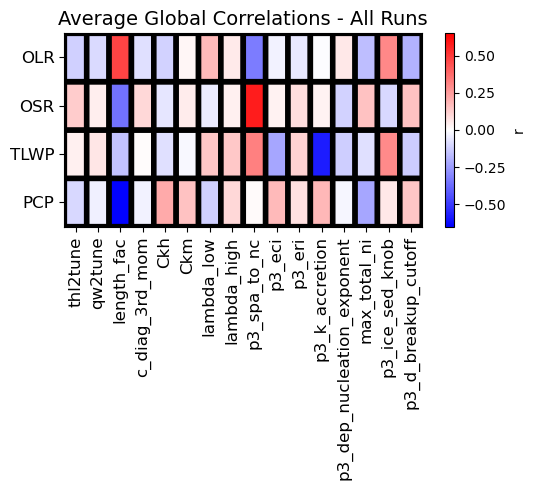

In [25]:
corr_matrix = plot_global_correlations(ppe_params, 
                    PCP_zrg_ppedataset, TLWP_zrg_ppedataset, OSR_zrg_ppedataset, OLR_zrg_ppedataset,
                    title = "Average Global Correlations - All Runs")


In [ ]:
def select_closest_runs(params_df, pcp_df, tlwp_df, osr_df, olr_df,
                        obs_pcp_df, obs_tlwp_df, obs_osr_df, obs_olr_df, n_closest=25):
    """
    Select the n_closest runs based on RMSE between model output and observations.
    """
    var_dfs = [pcp_df,     tlwp_df,     osr_df,     olr_df]
    obs_dfs = [obs_pcp_df, obs_tlwp_df, obs_osr_df, obs_olr_df]

    rmse = np.zeros(len(params_df))
    for df, obs_df in zip(var_dfs, obs_dfs):
        global_cols = df.filter(like='global')
        obs_global  = obs_df.filter(like='global').values.squeeze()
        rmse += ((global_cols.values - obs_global) ** 2).mean(axis=1)
    rmse = np.sqrt(rmse / len(var_dfs))

    closest_idx = np.argsort(rmse)[:n_closest]

    return (params_df.iloc[closest_idx],
            pcp_df.iloc[closest_idx],
            tlwp_df.iloc[closest_idx],
            osr_df.iloc[closest_idx],
            olr_df.iloc[closest_idx])

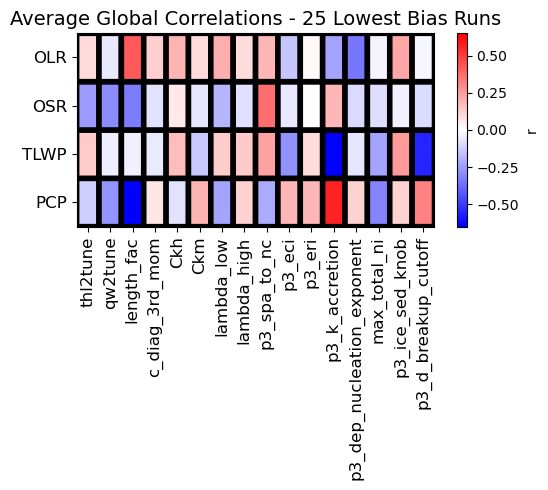

In [ ]:
params_c, pcp_c, tlwp_c, osr_c, olr_c = select_closest_runs(
    ppe_params, PCP_zrg_ppedataset, TLWP_zrg_ppedataset, OSR_zrg_ppedataset, OLR_zrg_ppedataset,
    PCP_zrg_obs, TLWP_zrg_obs, OSR_zrg_obs, OLR_zrg_obs,
    n_closest=25
)

corr_matrix_closest = plot_global_correlations(params_c, pcp_c, tlwp_c, osr_c, olr_c,
                                               title="Average Global Correlations - 25 Lowest Bias Runs")


### K-folding and Training preparation

In [27]:
folds = 5 # number of folds
kf = KFold(n_splits=folds, shuffle=True, random_state=2)
kf.get_n_splits(ppe_params)

k = 0 #just for example purposes, showing fold by fold, starting with the first one

for i, (train_index, test_index) in enumerate(kf.split(ppe_params)):
    if i == k:
        X_train = ppe_params.iloc[train_index]
        X_test = ppe_params.iloc[test_index]
        train_run_labels = X_train.index.to_list()
        test_run_labels = X_test.index.to_list()
        print('k =', i, test_run_labels)

        Y_train = zrg_ppedataset.loc[train_run_labels] #.to_array()
        Y_test = zrg_ppedataset.loc[test_run_labels] #.to_array()
        Y_train_array = Y_train.to_numpy()
        Y_test_array = Y_test.to_numpy()

        #Gridcell verison
        #Y_train = ppe_dataset_small.sel(run_label=train_run_labels) #.to_array()
        #Y_test = ppe_dataset_small.sel(run_label=test_run_labels) #.to_array()
        #Y_train_array = ppe_dataset_small.sel(run_label=train_run_labels).to_array()
        #Y_test_array = ppe_dataset_small.sel(run_label=test_run_labels).to_array()
        
        print("X_test shape:", X_test.shape, "type:", type(X_test))
        print("X_train shape:", X_train.shape, "type:", type(X_train))
        print("Y_test shape:", Y_test_array.shape, "type:", type(Y_test_array))
        print("Y_train shape:", Y_train_array.shape, "type:", type(Y_train_array))

k = 0 ['m0003', 'm0004', 'm0006', 'm0009', 'm0026', 'm0042', 'm0049', 'm0050', 'm0057', 'm0066', 'm0079', 'm0080', 'm0087', 'm0091', 'm0099', 'm0101', 'm0123', 'm0148', 'm0160', 'm0165', 'm0174', 'm0183', 'm0186', 'm0190', 'm0203', 'm0225', 'm0232', 'm0248', 'm0255', 'm0257', 'm0259']
X_test shape: (31, 16) type: <class 'pandas.core.frame.DataFrame'>
X_train shape: (122, 16) type: <class 'pandas.core.frame.DataFrame'>
Y_test shape: (31, 176) type: <class 'numpy.ndarray'>
Y_train shape: (122, 176) type: <class 'numpy.ndarray'>


In [28]:
PCP_train = PCP_zrg_ppedataset.loc[train_run_labels] #**(1/8)
TLWP_train = TLWP_zrg_ppedataset.loc[train_run_labels] #**(1/4)
OSR_train = OSR_zrg_ppedataset.loc[train_run_labels] #**(1/4)
OLR_train = OLR_zrg_ppedataset.loc[train_run_labels] #**(1/8) 

PCP_train.columns = PCP_zrg_ppedataset.columns.astype(str)
TLWP_train.columns = TLWP_zrg_ppedataset.columns.astype(str)
OSR_train.columns = OSR_zrg_ppedataset.columns.astype(str)
OLR_train.columns = OLR_zrg_ppedataset.columns.astype(str)

vars_train_list = [PCP_train, TLWP_train, OSR_train, OLR_train]

In [ ]:
PCP_test = PCP_zrg_ppedataset.loc[test_run_labels] #**(1/8) # could consider other preprocessing methods here
TLWP_test = TLWP_zrg_ppedataset.loc[test_run_labels] #**(1/4)
OSR_test = OSR_zrg_ppedataset.loc[test_run_labels] #**(1/4)
OLR_test = OLR_zrg_ppedataset.loc[test_run_labels] #**(1/8)

PCP_test.columns = PCP_zrg_ppedataset.columns.astype(str)
TLWP_test.columns = TLWP_zrg_ppedataset.columns.astype(str)
OSR_test.columns = OSR_zrg_ppedataset.columns.astype(str)
OLR_test.columns = OLR_zrg_ppedataset.columns.astype(str)

#vars_test_list = [PCP_test, TLWP_test, OSR_test, OLR_test]

In [31]:
#for random forest, no preprocessing will be used
Y_train_ZRG = np.stack((PCP_train, TLWP_train, OSR_train, OLR_train), axis = 0)
Y_train_ZRG = np.transpose(Y_train_ZRG, (1, 2, 0))
print(Y_train_ZRG.shape)

Y_test_ZRG = np.stack((PCP_test, TLWP_test, OSR_test, OLR_test), axis = 0)
Y_test_ZRG = np.transpose(Y_test_ZRG, (1, 2, 0))
print(Y_test_ZRG.shape)

(122, 44, 4)
(31, 44, 4)


In [32]:
range_thl2tune = [0.1, 10]
range_qw2tune = [0.1, 10]
range_length_fac = [0.1, 10]
range_c_diag_3rd_mom = [0.1, 10]
range_Ckh = [0.1, 1]
range_Ckm = [0.1, 1]
range_lambda_low = [0.0001, 0.1]
range_lambda_high = [0.0001, 0.1]
range_spa_to_nc = [0.1, 10]
range_p3_eci = [0.1, 1]
range_p3_eri = [0.1, 1]
range_k_acc = [0.01, 100]
range_p3_dep_nucleation_exponent = [0.2, 0.304]
range_max_total_ni = [5e5, 1e7]
#range_ice_sed_knob = [0.1, 2]
range_ice_sed_knob = [1, 2]
range_p3_d_breakup_cutoff = [0, 500e-6]

dict_range_pars = dict()
dict_range_pars['length_fac'] = range_length_fac
dict_range_pars['p3_spa_to_nc'] = range_spa_to_nc
dict_range_pars['p3_k_accretion'] = range_k_acc
dict_range_pars['p3_ice_sed_knob'] = range_ice_sed_knob
dict_range_pars['thl2tune'] = range_thl2tune
dict_range_pars['qw2tune'] = range_qw2tune
dict_range_pars['c_diag_3rd_mom'] = range_c_diag_3rd_mom
dict_range_pars['Ckh'] = range_Ckh
dict_range_pars['Ckm'] = range_Ckm
dict_range_pars['lambda_low'] = range_lambda_low
dict_range_pars['lambda_high'] = range_lambda_high
dict_range_pars['p3_eci'] = range_p3_eci
dict_range_pars['p3_eri'] = range_p3_eri
dict_range_pars['p3_dep_nucleation_exponent'] = range_p3_dep_nucleation_exponent
dict_range_pars['p3_d_breakup_cutoff'] = range_p3_d_breakup_cutoff
dict_range_pars['max_total_ni'] = range_max_total_ni

In [35]:
#Create bounds for minmax scaler -- using full bounds of parameters
param_bounds = np.array([dict_range_pars[param] for param in ppe_params.columns])

In [36]:
#transform data
X_pipe_sk_minmax = preprocessing.MinMaxScaler()
X_pipe_sk_minmax.fit(param_bounds.T)  # fit on lower and upper bounds (2,16)
X_train_norm = X_pipe_sk_minmax.transform(X_train)
X_test_norm = X_pipe_sk_minmax.transform(X_test)

#from scikitlearn
Y_pipe_sk_ss_PCP = preprocessing.StandardScaler()
Y_pipe_sk_ss_PCP.fit(PCP_train)
PCP_train_norm = Y_pipe_sk_ss_PCP.transform(PCP_train)
PCP_test_norm = Y_pipe_sk_ss_PCP.transform(PCP_test)

Y_pipe_sk_ss_TLWP = preprocessing.StandardScaler() #lots of other options for this: RobustScaler(), etc.
Y_pipe_sk_ss_TLWP.fit(TLWP_train)
TLWP_train_norm = Y_pipe_sk_ss_TLWP.transform(TLWP_train)
TLWP_test_norm = Y_pipe_sk_ss_TLWP.transform(TLWP_test)

Y_pipe_sk_ss_OSR = preprocessing.StandardScaler()
Y_pipe_sk_ss_OSR.fit(OSR_train)
OSR_train_norm = Y_pipe_sk_ss_OSR.transform(OSR_train)
OSR_test_norm = Y_pipe_sk_ss_OSR.transform(OSR_test)

Y_pipe_sk_ss_OLR = preprocessing.StandardScaler()
Y_pipe_sk_ss_OLR.fit(OLR_train)
OLR_train_norm = Y_pipe_sk_ss_OLR.transform(OLR_train)
OLR_test_norm = Y_pipe_sk_ss_OLR.transform(OLR_test)

Y_train_norm = np.stack((PCP_train_norm, TLWP_train_norm, OSR_train_norm, OLR_train_norm), axis = 0)
Y_train_norm = np.transpose(Y_train_norm, (1, 2, 0))
print(X_train_norm.shape, Y_train_norm.shape)

Y_test_norm = np.stack((PCP_test_norm, TLWP_test_norm, OSR_test_norm, OLR_test_norm), axis = 0)
Y_test_norm = np.transpose(Y_test_norm, (1, 2, 0))
print(X_test_norm.shape, Y_test_norm.shape)

(122, 16) (122, 44, 4)
(31, 16) (31, 44, 4)


/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


#### Saving transforms

In [99]:
### Saving projections both normed and not and R2s
timestamp_day = datetime.now().strftime("%Y-%m-%d")
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
#path - /global/cfs/cdirs/e3sm/jpaige3/ESEm/TF_saving/ --- REPLACE THIS PATH TO SAVE THE PIPELINE WITH THE MODEL
fold_filename = f"{paths.CV_RESULTS_DIR}/Fold_{k}_ZRG_masked_data_{timestamp}.pkl"

#make dictionary to save
fold_data_to_save = {
    'X_pipeline': X_pipe_sk_minmax, 
    'Y_pipeline_PCP': Y_pipe_sk_ss_PCP, 
    'Y_pipeline_TLWP': Y_pipe_sk_ss_TLWP, 
    'Y_pipeline_OSR': Y_pipe_sk_ss_OSR, 
    'Y_pipeline_OLR': Y_pipe_sk_ss_OLR,
    ####
    'X_train_index': train_run_labels,
    'X_test_index': test_run_labels,
    ### unnormalized/untransformed
    'X_train': X_train,
    'X_test': X_test,
    'Y_train': Y_train_ZRG,
    'Y_test': Y_test_ZRG,
    'PCP_train': PCP_train, 
    'TLWP_train': TLWP_train, 
    'OSR_train': OSR_train, 
    'OLR_train': OLR_train,
    'PCP_test': PCP_test, 
    'TLWP_test': TLWP_test, 
    'OSR_test': OSR_test, 
    'OLR_test': OLR_test,
    ### normalized/transformed
    'X_train_norm': X_train_norm,
    'X_test_norm': X_test_norm,
    'Y_train_norm': Y_train_norm,
    'Y_test_norm': Y_test_norm,
    'PCP_train_norm': PCP_train_norm, 
    'TLWP_train_norm': TLWP_train_norm, 
    'OSR_train_norm': OSR_train_norm, 
    'OLR_train_norm':OLR_train_norm,
    'PCP_test_norm': PCP_test_norm, 
    'TLWP_test_norm': TLWP_test_norm, 
    'OSR_test_norm': OSR_test_norm, 
    'OLR_test_norm':OLR_test_norm,
}

#save using pickle
with open(fold_filename, 'wb') as f:
    pickle.dump(fold_data_to_save, f)

#### Employing models

In [37]:
print(X_train_norm.shape, Y_train_norm.shape)
print(X_test_norm.shape, Y_test_norm.shape)

(122, 16) (122, 44, 4)
(31, 16) (31, 44, 4)


##### Model

In [ ]:
model_gp = gp_model(X_train_norm, Y_train_norm)
#model_cnn = cnn_model(X_train_norm, Y_train_norm)
#model_rf = rf_model(X_train.to_numpy(), Y_train_ZRG) #does not require preprocessing

InternalError: cudaSetDevice() on GPU:0 failed. Status: out of memory

In [143]:
model_gp.train()

In [49]:
#model_cnn.train()

Epoch 1/100


2026-03-10 13:17:41.150126: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.07MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-03-10 13:17:41.186566: W tensorflow/core/framework/op_kernel.cc:1839] OP_REQUIRES failed at xla_ops.cc:580 : UNKNOWN: Failed to determine best cudnn convolution algorithm for:
%cudnn-conv-bw-input.2 = (f32[8,12,50,4]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,12,50,4]{3,2,1,0} %transpose.36, f32[12,12,3,5]{3,2,1,0} %transpose.37), window={size=3x5 pad=1_1x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="decoder_1/conv2d_transpose_1/conv_transpose" source_file="/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1177}, backend_config={

UnknownError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/runpy.py", line 198, in _run_module_as_main

  File "/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/runpy.py", line 88, in _run_code

  File "/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/global/homes/j/jpaige3/.conda/envs/ESEm/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/global/homes/j/jpaige3/.conda/envs/E

In [48]:
#model_rf.train()

### In sample $R^2$

In [119]:
m_gp, v_gp = model_gp.predict(X_train_norm)

In [70]:
#vars_list = ['PCP','TLWP', 'OSR', 'OLR']
PCP_proj_norm_gp = pd.DataFrame(m_gp[:, :, 0], index = X_train.index)
TLWP_proj_norm_gp = pd.DataFrame(m_gp[:, :, 1], index = X_train.index)
OSR_proj_norm_gp = pd.DataFrame(m_gp[:, :, 2], index = X_train.index)
OLR_proj_norm_gp = pd.DataFrame(m_gp[:, :, 3], index = X_train.index)

PCP_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 0], index = X_train.index)
TLWP_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 1], index = X_train.index)
OSR_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 2], index = X_train.index)
OLR_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 3], index = X_train.index)

In [71]:
#Normalied space
#Variance weighted -- lots of flexibility in the definition of this
PCP_r_squared_vw = r2_score(PCP_train_norm, PCP_proj_norm_gp, multioutput='variance_weighted')
PCP_rmse = root_mean_squared_error(PCP_train_norm, PCP_proj_norm_gp)

TLWP_r_squared_vw = r2_score(TLWP_train_norm, TLWP_proj_norm_gp, multioutput='variance_weighted')
TLWP_rmse = root_mean_squared_error(TLWP_train_norm, TLWP_proj_norm_gp)

OSR_r_squared_vw = r2_score(OSR_train_norm, OSR_proj_norm_gp, multioutput='variance_weighted')
OSR_rmse = root_mean_squared_error(OSR_train_norm, OSR_proj_norm_gp)

OLR_r_squared_vw = r2_score(OLR_train_norm, OLR_proj_norm_gp, multioutput='variance_weighted')
OLR_rmse = root_mean_squared_error(OLR_train_norm, OLR_proj_norm_gp)

print('PCP:', PCP_r_squared_vw, 'TLWP:', TLWP_r_squared_vw, 'OSR:', OSR_r_squared_vw, 'OLR:', OLR_r_squared_vw)
print('PCP:', PCP_rmse, 'TLWP:', TLWP_rmse, 'OSR:', OSR_rmse, 'OLR:', OLR_rmse)


PCP: 0.9999974370002747 TLWP: 0.9999979138374329 OSR: 0.9999978542327881 OLR: 0.9999960064888
PCP: 0.0015354664803777598 TLWP: 0.0014316257897578472 OSR: 0.0014081468961752623 OLR: 0.0019530146802001914


In [54]:
#Non-normalized space
PCP_proj_gp = pd.DataFrame(Y_pipe_sk_ss_PCP.inverse_transform(PCP_proj_norm_gp))
PCP_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_PCP.inverse_transform(PCP_v_proj_norm_gp))

TLWP_proj_gp = pd.DataFrame(Y_pipe_sk_ss_TLWP.inverse_transform(TLWP_proj_norm_gp))
TLWP_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_TLWP.inverse_transform(TLWP_v_proj_norm_gp))

OSR_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OSR.inverse_transform(OSR_proj_norm_gp))
OSR_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OSR.inverse_transform(OSR_v_proj_norm_gp))

OLR_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OLR.inverse_transform(OLR_proj_norm_gp))
OLR_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OLR.inverse_transform(OLR_v_proj_norm_gp))

#NOTE (unchecked Claude):  inverse_transform on a StandardScaler performs X * std + mean, which is the correct inverse for a mean but not the correct inverse for a variance. 
#For variances, you need to multiply by std**2 (i.e., variance_physical = variance_normalized * scaler.scale_**2). 
#So inverse_transform would give the wrong result for variance.

In [55]:
PCP_r_squared_vw_phys = r2_score(PCP_train, PCP_proj_gp, multioutput='variance_weighted') # = 'raw_values')
PCP_rmse_phys = root_mean_squared_error(PCP_train, PCP_proj_gp)

TLWP_r_squared_vw_phys = r2_score(TLWP_train, TLWP_proj_gp, multioutput='variance_weighted')
TLWP_rmse_phys = root_mean_squared_error(TLWP_train, TLWP_proj_gp)

OSR_r_squared_vw_phys = r2_score(OSR_train, OSR_proj_gp, multioutput='variance_weighted')
OSR_rmse_phys = root_mean_squared_error(OSR_train, OSR_proj_gp)

OLR_r_squared_vw_phys = r2_score(OLR_train, OLR_proj_gp, multioutput='variance_weighted')
OLR_rmse_phys = root_mean_squared_error(OLR_train, OLR_proj_gp)

print('PCP:', PCP_r_squared_vw_phys, 'TLWP:', TLWP_r_squared_vw_phys, 'OSR:', OSR_r_squared_vw_phys, 'OLR:', OLR_r_squared_vw_phys)
print('PCP:', PCP_rmse_phys, 'TLWP:', TLWP_rmse_phys, 'OSR:', OSR_rmse_phys, 'OLR:', OLR_rmse_phys)


PCP: 0.9999983803488562 TLWP: 0.9999979552839983 OSR: 0.9999976823796478 OLR: 0.9999956690756201
PCP: 4.330484699704375e-12 TLWP: 2.340678008500172e-05 OSR: 0.014549719083278942 OLR: 0.01239095460946512


### Out of sample $R^2$

In [144]:
m_gp, v_gp = model_gp.predict(X_test_norm)

In [130]:
PCP_proj_norm_gp = m_gp

In [145]:
#vars_list = ['PCP','TLWP', 'OSR', 'OLR']
PCP_proj_norm_gp = pd.DataFrame(m_gp[:, :, 0], index = X_test.index)
TLWP_proj_norm_gp = pd.DataFrame(m_gp[:, :, 1], index = X_test.index)
OSR_proj_norm_gp = pd.DataFrame(m_gp[:, :, 2], index = X_test.index)
OLR_proj_norm_gp = pd.DataFrame(m_gp[:, :, 3], index = X_test.index)

PCP_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 0], index = X_test.index)
TLWP_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 1], index = X_test.index)
OSR_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 2], index = X_test.index)
OLR_v_proj_norm_gp = pd.DataFrame(v_gp[:, :, 3], index = X_test.index)

In [ ]:
#Normalied space
#Variance weighted -- lots of flexibility in the definition of this
PCP_r_squared_vw = r2_score(PCP_test_norm, PCP_proj_norm_gp, multioutput='raw_values') #'variance_weighted')
PCP_rmse = root_mean_squared_error(PCP_test_norm, PCP_proj_norm_gp)

TLWP_r_squared_vw = r2_score(TLWP_test_norm, TLWP_proj_norm_gp, multioutput='raw_values')
TLWP_rmse = root_mean_squared_error(TLWP_test_norm, TLWP_proj_norm_gp)

OSR_r_squared_vw = r2_score(OSR_test_norm, OSR_proj_norm_gp, multioutput='raw_values')
OSR_rmse = root_mean_squared_error(OSR_test_norm, OSR_proj_norm_gp)

OLR_r_squared_vw = r2_score(OLR_test_norm, OLR_proj_norm_gp, multioutput='raw_values')
OLR_rmse = root_mean_squared_error(OLR_test_norm, OLR_proj_norm_gp)

print('PCP:', PCP_r_squared_vw, 'TLWP:', TLWP_r_squared_vw, 'OSR:', OSR_r_squared_vw, 'OLR:', OLR_r_squared_vw)
print('PCP:', PCP_rmse, 'TLWP:', TLWP_rmse, 'OSR:', OSR_rmse, 'OLR:', OLR_rmse)


PCP: 0.828961968421936 TLWP: 0.8185929656028748 OSR: 0.6930254697799683 OLR: 0.5063021183013916
PCP: 0.4211941373340491 TLWP: 0.427192165450148 OSR: 0.7656994033426563 OLR: 1.2866310051501522


In [35]:
#Non-normalized space
PCP_proj_gp = pd.DataFrame(Y_pipe_sk_ss_PCP.inverse_transform(PCP_proj_norm_gp))
PCP_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_PCP.inverse_transform(PCP_v_proj_norm_gp))

TLWP_proj_gp = pd.DataFrame(Y_pipe_sk_ss_TLWP.inverse_transform(TLWP_proj_norm_gp))
TLWP_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_TLWP.inverse_transform(TLWP_v_proj_norm_gp))

OSR_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OSR.inverse_transform(OSR_proj_norm_gp))
OSR_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OSR.inverse_transform(OSR_v_proj_norm_gp))

OLR_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OLR.inverse_transform(OLR_proj_norm_gp))
OLR_v_proj_gp = pd.DataFrame(Y_pipe_sk_ss_OLR.inverse_transform(OLR_v_proj_norm_gp))

#NOTE (unchecked Claude):  inverse_transform on a StandardScaler performs X * std + mean, which is the correct inverse for a mean but not the correct inverse for a variance. 
#For variances, you need to multiply by std**2 (i.e., variance_physical = variance_normalized * scaler.scale_**2). 
#So inverse_transform would give the wrong result for variance.

In [ ]:
PCP_r_squared_vw_phys = r2_score(PCP_test, PCP_proj_gp, multioutput='raw_values') #='variance_weighted') # = 'raw_values')
PCP_rmse_phys = root_mean_squared_error(PCP_test, PCP_proj_gp)

TLWP_r_squared_vw_phys = r2_score(TLWP_test, TLWP_proj_gp, multioutput='raw_values')
TLWP_rmse_phys = root_mean_squared_error(TLWP_test, TLWP_proj_gp)

OSR_r_squared_vw_phys = r2_score(OSR_test, OSR_proj_gp, multioutput='raw_values')
OSR_rmse_phys = root_mean_squared_error(OSR_test, OSR_proj_gp)

OLR_r_squared_vw_phys = r2_score(OLR_test, OLR_proj_gp, multioutput='raw_values')
OLR_rmse_phys = root_mean_squared_error(OLR_test, OLR_proj_gp)

print('PCP:', PCP_r_squared_vw_phys, 'TLWP:', TLWP_r_squared_vw_phys, 'OSR:', OSR_r_squared_vw_phys, 'OLR:', OLR_r_squared_vw_phys)
print('PCP:', PCP_rmse_phys, 'TLWP:', TLWP_rmse_phys, 'OSR:', OSR_rmse_phys, 'OLR:', OLR_rmse_phys)


PCP: 0.7859250951277207 TLWP: 0.8643583558962253 OSR: 0.47580882829825544 OLR: 0.3355886320761142
PCP: 1.4585192700943436e-09 TLWP: 0.006332211354154024 OSR: 4.330335357502052 OLR: 3.0433697946988825


In [108]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
r2output_filename = f"{paths.CV_RESULTS_DIR}/GP/GP_ZRG_r2output_varweight_k={k}_{timestamp}.json"

r2_data = {
    "timestamp": timestamp,
    "model": "Gaussian Process",
    "metrics": {
        "PCP_r2_score": PCP_r_squared_vw,
        "TLWP_r2_score": TLWP_r_squared_vw,
        "OSR_r2_score": OSR_r_squared_vw,
        "OLR_r2_score": OLR_r_squared_vw,
        
        "PCP_rmse": PCP_rmse,
        "TLWP_rmse": TLWP_rmse,
        "OSR_rmse": OSR_rmse,
        "OLR_rmse": OLR_rmse,
        
        "PCP_r2_score_phys": PCP_r_squared_vw_phys,
        "TLWP_r2_score_phys": TLWP_r_squared_vw_phys,
        "OSR_r2_score_phys": OSR_r_squared_vw_phys,
        "OLR_r2_score_phys": OLR_r_squared_vw_phys,
        
        "PCP_rmse_phys": PCP_rmse_phys,
        "TLWP_rmse_phys": TLWP_rmse_phys,
        "OSR_rmse_phys": OSR_rmse_phys,
        "OLR_rmse_phys": OLR_rmse_phys,
    },
    #"params": model.get_params()
}

with open(r2output_filename, "w") as f:
    json.dump(r2_data, f, indent=2)

### Load back in

In [71]:
# Load in saved summary data
#cv_summary_file = '/global/cfs/cdirs/e3sm/jpaige3/ESEm/CV_Saved_Model_Data_masked/CV_summary_2026-04-02_22-57-20.json'
cv_summary_file = f"{paths.CV_RESULTS_DIR}/CV_summary_2026-04-02_23-49-03.json"

with open(cv_summary_file) as f:
    cv_summary = json.load(f)

# Flatten {model: [fold_dict, ...]} into a single DataFrame
records = []
for model, fold_list in cv_summary.items():
    records.extend(fold_list)

df_folds = pd.DataFrame(records)
print(f"Loaded {len(df_folds)} fold records | models: {df_folds['model'].unique()}")
df_folds

Loaded 25 fold records | models: ['GP' 'CNN' 'RF' 'MLR' 'Spline']


,model,fold,PCP_train_r2_norm,PCP_train_rmse_norm,PCP_train_r2_phys,PCP_train_rmse_phys,TLWP_train_r2_norm,TLWP_train_rmse_norm,TLWP_train_r2_phys,TLWP_train_rmse_phys,...,TLWP_test_r2_phys,TLWP_test_rmse_phys,OSR_test_r2_norm,OSR_test_rmse_norm,OSR_test_r2_phys,OSR_test_rmse_phys,OLR_test_r2_norm,OLR_test_rmse_norm,OLR_test_r2_phys,OLR_test_rmse_phys
0,GP,0,0.998436,0.037151,0.999052,1.224489e-10,0.998726,0.035316,0.998677,0.000772,...,0.861099,0.006416,0.461270,0.406427,0.489939,4.312096,0.308754,0.457828,0.364568,3.027933
1,GP,1,0.999999,0.000974,0.999999,3.340835e-12,0.999999,0.000847,0.999999,0.000017,...,0.864722,0.008126,0.753645,0.473520,0.726111,4.963640,0.561194,0.556538,0.477275,3.794070
2,GP,2,0.971454,0.158817,0.982043,4.355280e-10,0.978116,0.147247,0.978556,0.002910,...,0.713238,0.012134,0.771600,0.666712,0.795166,5.745093,0.640996,1.031889,0.691747,5.153499
3,GP,3,1.000000,0.000630,1.000000,2.184395e-12,1.000000,0.000642,1.000000,0.000013,...,0.678251,0.009977,0.704020,0.363048,0.702078,3.738847,0.517916,0.307088,0.440137,2.093153
4,GP,4,0.999999,0.000809,1.000000,2.633723e-12,0.999999,0.000835,0.999999,0.000018,...,0.844508,0.007738,0.762655,0.568367,0.777310,5.364165,0.603701,0.761068,0.652640,4.428090
5,CNN,0,0.538330,0.676802,0.570601,2.487166e-09,0.663517,0.578041,0.677818,0.012337,...,0.556677,0.011042,0.349371,0.448434,0.393125,4.680140,0.508632,0.371081,0.669334,2.241427
6,CNN,1,0.523480,0.687131,0.570364,2.540503e-09,0.631972,0.603638,0.666425,0.011889,...,0.665981,0.013226,0.530008,0.669474,0.528801,6.637645,0.532443,0.574934,0.602845,3.500080
7,CNN,2,0.539367,0.676125,0.575582,2.032628e-09,0.675941,0.566952,0.693957,0.011117,...,0.537264,0.015824,0.244532,1.257277,0.282968,10.943839,0.177311,1.626309,0.220412,8.282921
8,CNN,3,0.547454,0.670173,0.581453,2.570336e-09,0.679038,0.564563,0.703384,0.011686,...,0.510230,0.012904,-0.008488,0.664090,0.021217,6.691000,0.296129,0.359936,0.437036,2.215690
9,CNN,4,0.532459,0.680587,0.565418,2.478530e-09,0.663782,0.577812,0.676565,0.011874,...,0.611846,0.012718,0.593016,0.751921,0.586495,7.271337,0.514408,0.838921,0.532636,5.026934


In [72]:
# ── Averages and std across folds, grouped by model ──────────────────────────
metric_cols = [c for c in df_folds.columns if c not in ('model', 'fold')]

df_mean = df_folds.groupby('model')[metric_cols].mean()
df_std  = df_folds.groupby('model')[metric_cols].std()

display(df_mean.round(4).filter(like='test_r2_norm'))
display(df_mean.round(4).filter(like='test_r2_phys'))
display(df_mean.round(4).filter(like='test_rmse_norm'))
display(df_mean.round(4).filter(like='test_rmse_phys'))
#display(df_std.round(4))

,PCP_test_r2_norm,TLWP_test_r2_norm,OSR_test_r2_norm,OLR_test_r2_norm
model,,,,
CNN,0.4561,0.5561,0.3417,0.4058
GP,0.6549,0.7950,0.6906,0.5265
MLR,0.3201,0.5909,0.2990,0.1880
RF,NaN,NaN,NaN,NaN
Spline,0.5489,0.7802,0.4808,0.0593


,PCP_test_r2_phys,TLWP_test_r2_phys,OSR_test_r2_phys,OLR_test_r2_phys
model,,,,
CNN,0.5040,0.5764,0.3625,0.4925
GP,0.7976,0.7924,0.6981,0.5253
MLR,0.3527,0.6388,0.3175,0.2487
RF,0.6363,0.3664,0.6780,0.5073
Spline,0.7035,0.7806,0.5064,0.0905


,PCP_test_rmse_norm,TLWP_test_rmse_norm,OSR_test_rmse_norm,OLR_test_rmse_norm
model,,,,
CNN,0.7263,0.6475,0.7582,0.7542
GP,0.5012,0.4320,0.4956,0.6229
MLR,0.7923,0.6228,0.7826,0.8292
RF,NaN,NaN,NaN,NaN
Spline,0.5880,0.4412,0.6273,0.8118


,PCP_test_rmse_phys,TLWP_test_rmse_phys,OSR_test_rmse_phys,OLR_test_rmse_phys
model,,,,
CNN,0.0,0.0131,7.2448,4.2534
GP,0.0,0.0089,4.8248,3.6993
MLR,0.0,0.0124,7.5365,4.7688
RF,0.0,0.0161,5.2631,3.9889
Spline,0.0,0.0091,6.1110,4.8193
